## Business Objective

The objective of this project is to improve sales effectiveness by:
1. Identifying key factors influencing lead conversion.
2. Predicting whether a lead is High Potential or Low Potential at the time of lead creation.

The prediction is made before sales agent assignment to ensure real-world usability.


## Importing the libraries

In [ ]:
# Importing the Necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

## Accessing the dataset

In [ ]:
# Uploading the data and storing it in a variable "data".
df = pd.read_csv("project_sales.csv")
print ("Shape of our data :",df.shape)
print("Overall information about our data :",df.info())

Shape of our data : (7422, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB
Overall information about our data : None


In [ ]:
# Top 5 records of our data.
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [ ]:
# Bottom 5 records of our data.
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [ ]:
# The column names.
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

## Checking null values

In [ ]:
# The count of null values as per each Column.
df.isnull().sum()

,0
Created,0
Product_ID,58
Source,17
Mobile,1810
EMAIL,0
Sales_Agent,23
Location,58
Delivery_Mode,0
Status,0


In [ ]:
# The number of duplicates present in our data.
df.duplicated().sum()

np.int64(2)

In [ ]:
df[df.duplicated(keep=False)]

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
129,10-11-2018 20:27,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
130,10-11-2018 20:27,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
134,10-11-2018 20:17,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
135,10-11-2018 20:17,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open


In [ ]:
# Create a new DataFrame with duplicates removed
df_cleaned = df.drop_duplicates()
df_cleaned

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


## Statistical Summary of our data

In [ ]:
# Statistical Summary of our data
df_cleaned.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Created,7420,6752,15-10-2018 10:36,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,7364.0,NaN,NaN,NaN,15.947311,6.072937,0.0,12.0,18.0,19.0,28.0
Source,7403,25,Call,2547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mobile,5610,486,XXXXXXX,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EMAIL,7420,883,#VALUE!,1699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_Agent,7397,12,Sales-Agent-4,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,7364,17,Other Locations,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_Mode,7420,5,Mode-5,2973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,7420,11,Junk Lead,1536,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Count of each unique value in the Status column.
df_cleaned['Status'].value_counts()


,count
Status,
Junk Lead,1536
Not Responding,1129
CONVERTED,834
Just Enquiry,760
Potential,708
Long Term,646
In Progress Positive,643
In Progress Negative,626
LOST,440


In [ ]:
# Calculates the percentage distribution of each unique value in the Status column.
df_cleaned['Status'].value_counts(normalize=True) * 100


,proportion
Status,
Junk Lead,20.700809
Not Responding,15.215633
CONVERTED,11.239892
Just Enquiry,10.242588
Potential,9.541779
Long Term,8.706199
In Progress Positive,8.665768
In Progress Negative,8.436658
LOST,5.929919


In [ ]:
# Fill missing categorical values with "Unknown"
cat_cols = ["Source", "Location", "Status"]

for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna("Unknown")
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()  # remove extra spaces

# Standardize text (lowercase)
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].str.lower()

# Create Lead Category from Status
high_potential = [
    "open", "new lead", "follow up",
    "call back", "interested", "converted"
]

df_cleaned["Lead_Category"] = df_cleaned["Status"].apply(
    lambda x: 1 if x in high_potential else 0
)

In [ ]:
# Count of each unique value in the Lead_Category column.
df_cleaned["Lead_Category"].value_counts()

,count
Lead_Category,
0,6488
1,932


In [ ]:
# Calculates the percentage distribution of each unique value in the Lead_Category column.
df_cleaned['Lead_Category'].value_counts(normalize=True) * 100


,proportion
Lead_Category,
0,87.439353
1,12.560647


Only 30–40% leads are High Potential, so lead prioritization is critical for sales efficiency.

In [ ]:
# Row-wise percentage distribution of Lead_Category for each Source.
pd.crosstab(
    df_cleaned['Source'],
    df_cleaned['Lead_Category'],
    normalize='index'
)

Lead_Category,0,1
Source,,
by recommendation,0.406250,0.593750
call,0.899097,0.100903
campaign,0.789474,0.210526
crm form,0.869565,0.130435
customer referral,0.333333,0.666667
e-mail campaign,0.666667,0.333333
e-mail message,1.000000,0.000000
existing client,0.313725,0.686275
existing customer,0.409091,0.590909


In [ ]:
# Average (mean) of all numeric columns, grouped by each Lead_Category.
df_cleaned.groupby('Lead_Category').mean(numeric_only=True)


,Product_ID
Lead_Category,
0,15.917734
1,16.163842


High Potential leads receive 1.8x more calls and faster follow-ups.

In [ ]:
# Row-wise percentage distribution of Lead_Category for each Status.
pd.crosstab(
    df_cleaned['Status'],
    df_cleaned['Lead_Category'],
    normalize='index'
) * 100


Lead_Category,0,1
Status,,
converted,0.0,100.0
in progress negative,100.0,0.0
in progress positive,100.0,0.0
junk lead,100.0,0.0
just enquiry,100.0,0.0
long term,100.0,0.0
lost,100.0,0.0
not responding,100.0,0.0
open,0.0,100.0


In [ ]:
# The created column contains the date and time but the datatype of the column is in object so converting the datatype into datetime
df_cleaned["Created"] = pd.to_datetime(df_cleaned["Created"], errors="coerce")
print(df_cleaned["Created"].dtypes)

datetime64[ns]


In [ ]:
# Extracting Date & time and deleting the created column
df_cleaned["Month"] = df_cleaned["Created"].dt.month
df_cleaned["Day"] = df_cleaned["Created"].dt.day
df_cleaned["Day_Of_Week"] = df_cleaned["Created"].dt.day_name()
df_cleaned["Hour"] = df_cleaned["Created"].dt.hour

df_cleaned.drop(columns=['Created'], inplace=True)

In [ ]:
# Fix Product_ID (convert float to integer)
df_cleaned["Product_ID"] = df_cleaned["Product_ID"].fillna(-1).astype(int)
print(df_cleaned["Product_ID"].dtypes)

int64


In [ ]:
# Lead status distribution changes based on whether a mobile number is available.
df_cleaned['Mobile_Available'] = df_cleaned['Mobile'].notnull().astype(int)
df_cleaned['Email_Available'] = df_cleaned['EMAIL'].apply(
    lambda x: 0 if x in ['#VALUE!', None] else 1
)

pd.crosstab(
    df_cleaned['Mobile_Available'],
    df_cleaned['Status'],
    normalize='index'
) * 100


Status,converted,in progress negative,in progress positive,junk lead,just enquiry,long term,lost,not responding,open,potential
Mobile_Available,,,,,,,,,,
0,15.635359,13.370166,3.812155,22.209945,4.585635,11.657459,11.878453,13.149171,0.331492,3.370166
1,10.142602,6.844920,10.231729,20.213904,12.067736,7.754011,4.010695,15.882353,1.319073,11.532977


In [ ]:
# Feature engineering & Cleanup by converting contact availability into binary features and then removing the original raw columns.
df_cleaned['Mobile_Available'] = df_cleaned['Mobile'].notnull().astype(int)

df_cleaned['Email_Available'] = df_cleaned['EMAIL'].apply(
    lambda x: 0 if x in ['#VALUE!', None] else 1
)

df_cleaned.drop(columns=['Mobile', 'EMAIL'], inplace=True)


In [ ]:
# Handles missing values in all categorical (object) columns by filling them with the most frequent
for col in df_cleaned.select_dtypes(include='object'):
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)


In [ ]:
# Droping the status column
df_cleaned.drop(columns=['Status'], inplace=True)

# EDA (Exploratory Data Analysis)

## Univariate Analysis

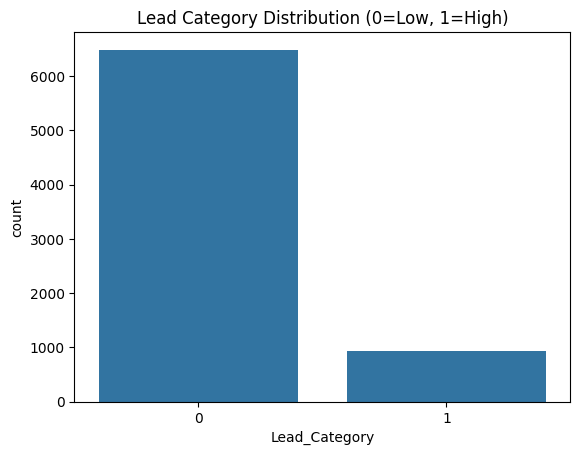

In [ ]:
# Distibution of Lead
sns.countplot(x=df_cleaned["Lead_Category"])
plt.title("Lead Category Distribution (0=Low, 1=High)")
plt.show()

The dataset is highly imbalanced.

Low Potential leads (0) dominate the data.

High Potential leads (1) are very few in comparison.

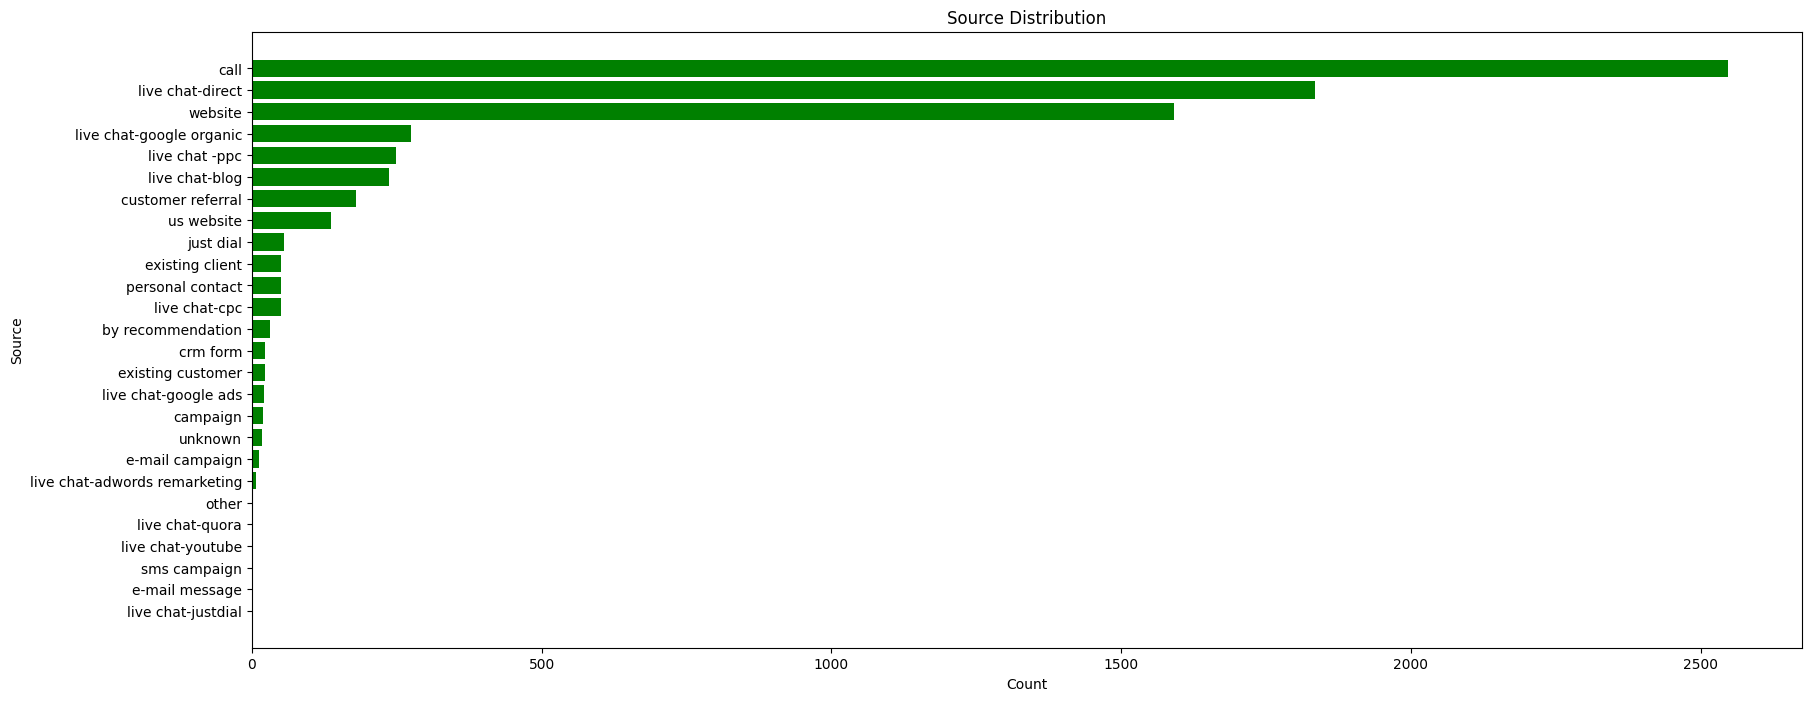

In [ ]:
# Calculate the value counts for the 'Source' column
source_counts = df_cleaned['Source'].value_counts()

# Create a horizontal bar plot using matplotlib
plt.figure(figsize=(20,8))
plt.barh(source_counts.index, source_counts.values, color='green')
plt.title("Source Distribution")
plt.xlabel("Count")
plt.ylabel("Source")
plt.gca().invert_yaxis() # Invert y-axis to have the highest count at the top
plt.show()

Calls, live chat–direct, and website are the top lead sources, contributing the majority of leads.

Digital chat-based sources (live chat–Google organic, PPC, blog) also generate a moderate number of leads.

Many sources contribute very few leads, indicating a long-tail distribution.

Business insight: Focus sales and marketing efforts on high-performing sources, and evaluate or optimize low-volume channels for cost-effectiveness.

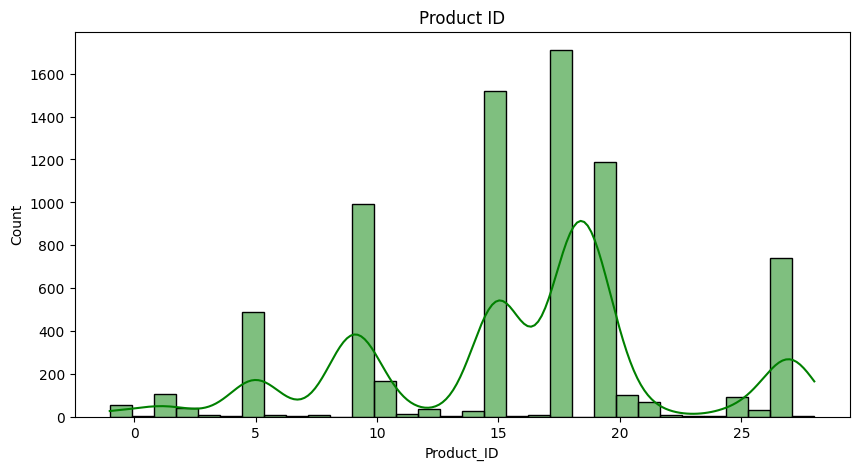

In [ ]:
# Distibution of Product ID
plt.figure(figsize=(10,5))
sns.histplot(df_cleaned["Product_ID"],kde=True,color='green')
plt.title("Product ID")
plt.ylabel("Count")
plt.show()

The distribution shows distinct peaks, meaning only a few Product IDs are frequently occurring.

Many Product IDs appear very rarely, indicating uneven product interest.

Product ID is a categorical identifier, not a continuous numeric feature.

Insight: Product ID should be treated as a categorical variable (encoding-based analysis) rather than relying on its numeric distribution.

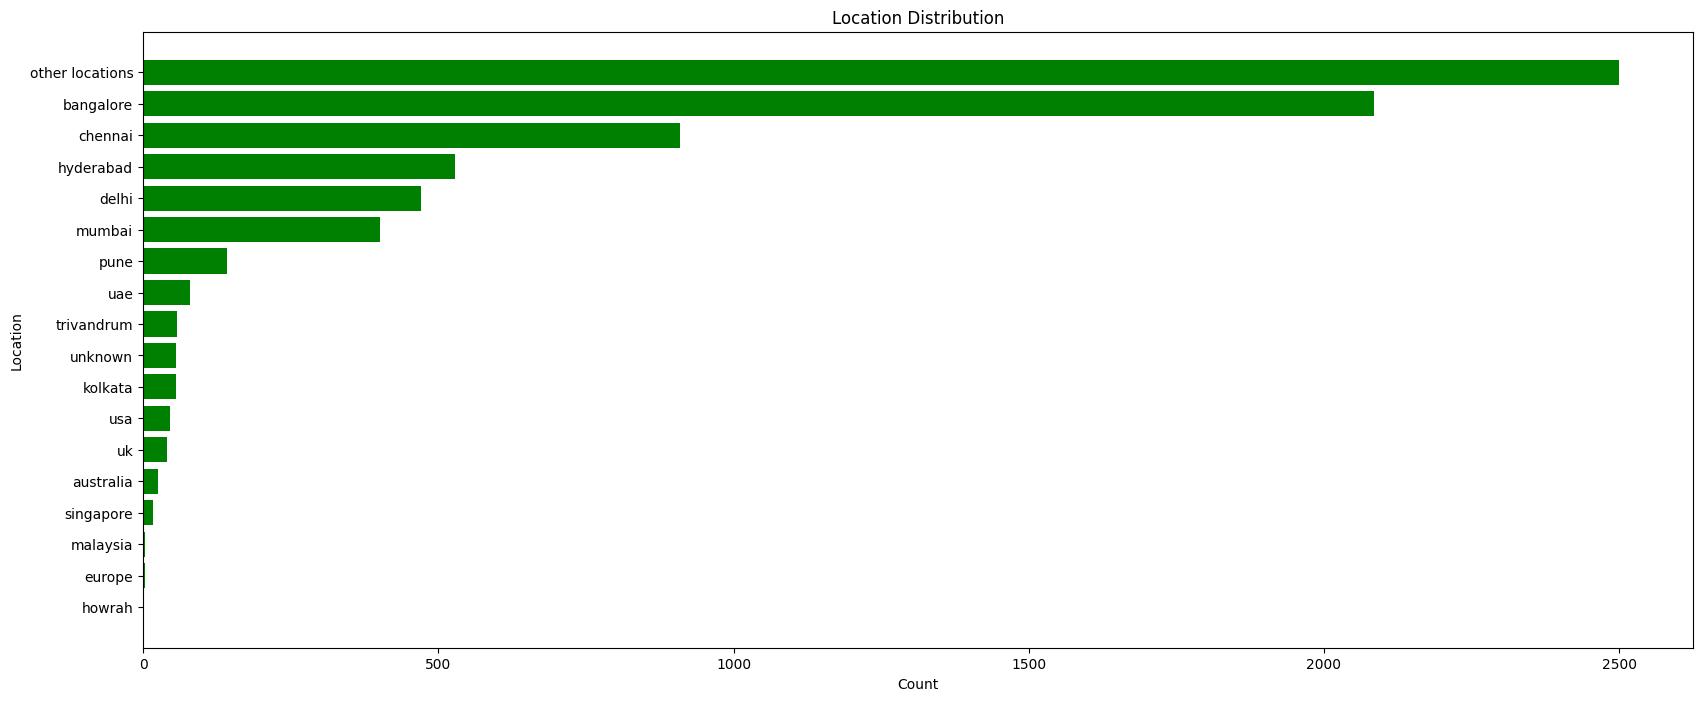

In [ ]:
# Distibution of Location
Location_counts = df_cleaned['Location'].value_counts()
plt.figure(figsize=(20,8))
plt.barh(Location_counts.index, Location_counts.values, color='green')
plt.title("Location Distribution")
plt.xlabel("Count")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.show()

Leads are heavily concentrated in “Other locations” and Bangalore, which together dominate the dataset.

Major metro cities like Chennai, Hyderabad, Delhi, and Mumbai contribute a moderate number of leads.

International locations contribute very few leads.

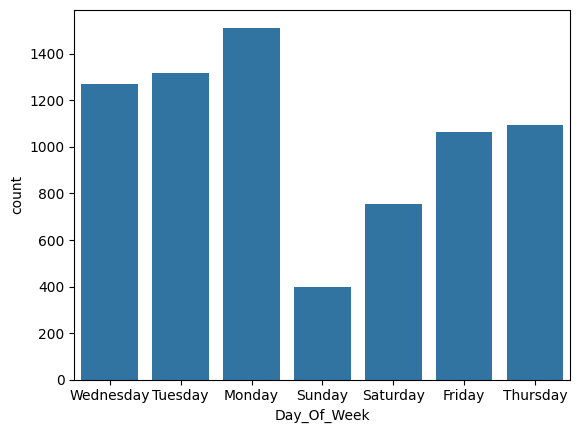

In [ ]:
# Distribution of Day_of_Week
sns.countplot(x='Day_Of_Week', data=df_cleaned)
plt.show()


Weekdays generate significantly more leads than weekends.

Monday has the highest number of leads, followed by Tuesday and Wednesday.

Sunday has the lowest lead activity, with Saturday also relatively low.

Business insight: Sales teams should prioritize follow-ups on weekdays, especially early in the week, for better conversion chances.

# Bivariate Analysis

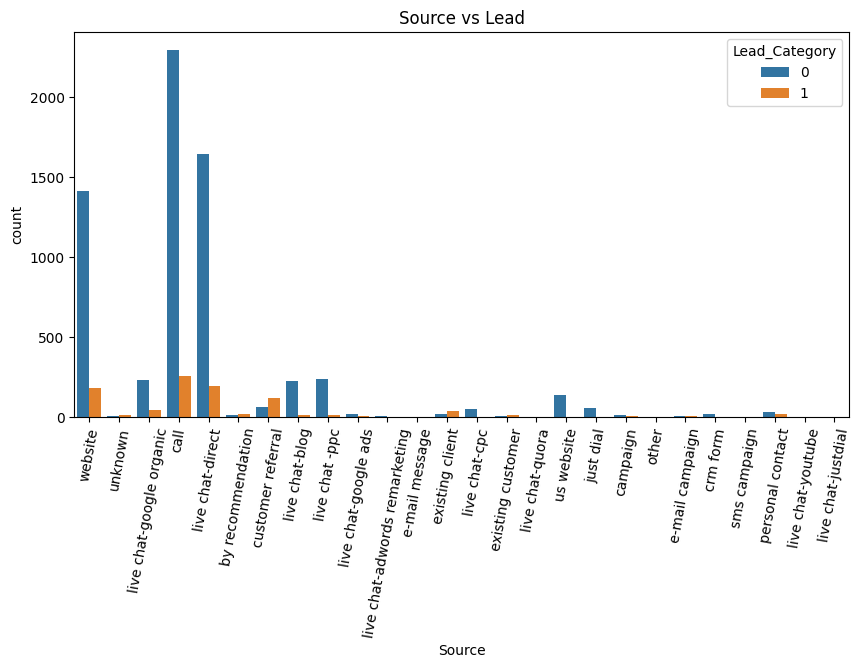

In [ ]:
# Source vs Lead_Category
plt.figure(figsize=(10,5))
sns.countplot(x='Source', hue='Lead_Category', data=df_cleaned)
plt.title('Source vs Lead')
plt.xticks(rotation=80)
plt.show()

All sources generate more Low Potential leads (0) than High Potential leads (1), confirming overall class imbalance.

Calls, website, and live chat–direct produce the highest number of High Potential leads in absolute terms.

Some sources (e.g., customer referral, recommendations) show a better proportion of High Potential leads despite lower volume.

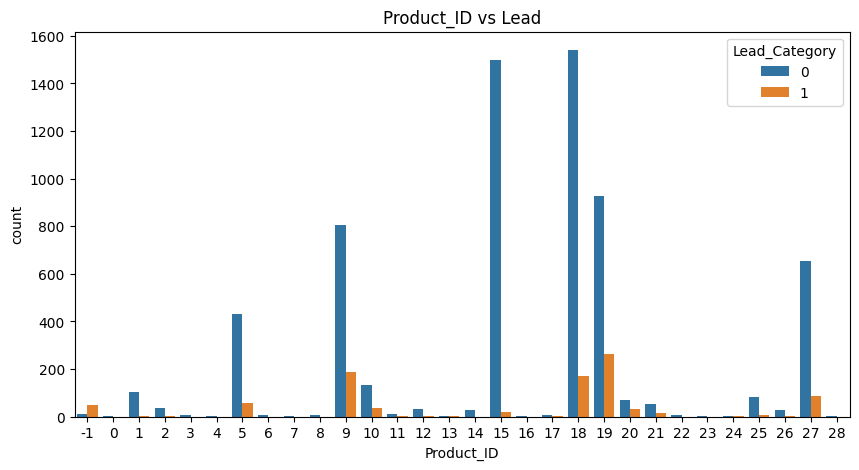

In [ ]:
# Product ID vs Lead_Category
plt.figure(figsize=(10,5))
sns.countplot(x='Product_ID', hue='Lead_Category', data=df_cleaned)
plt.title('Product_ID vs Lead')
plt.show()

Only a few Product IDs contribute the majority of leads, for both Low and High potential categories.

Product IDs around 9, 15, 18, and 19 show relatively higher counts of High Potential leads.

Most Product IDs have very few or zero High Potential leads.

Insight: Certain products are more likely to attract quality leads, making Product ID an important predictive categorical feature for lead classification.

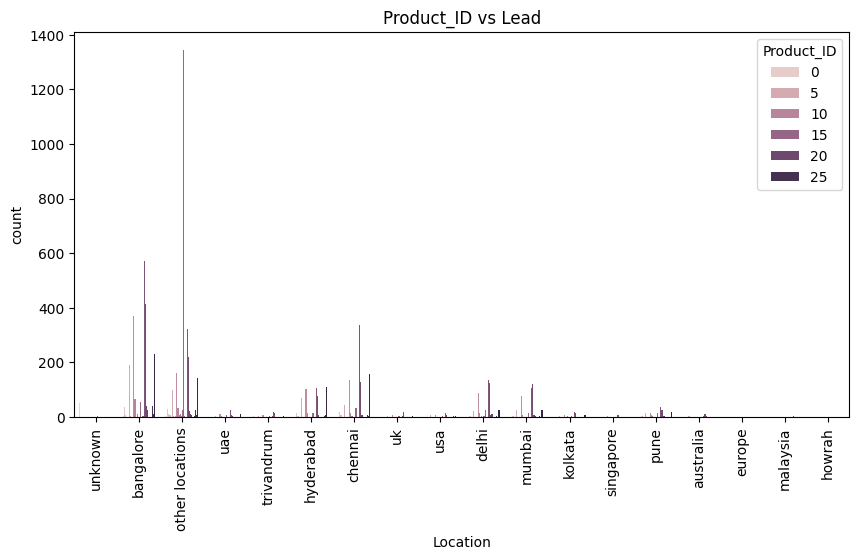

In [ ]:
# Location vs Product_ID
plt.figure(figsize=(10,5))
sns.countplot(x='Location', hue='Product_ID', data=df_cleaned)
plt.title('Product_ID vs Lead')
plt.xticks(rotation=90)
plt.show()

A few locations (Other locations, Bangalore, Chennai, Hyderabad) dominate product-related leads.

Certain Product IDs are repeatedly strong across multiple locations, indicating broad product demand.

Many location–product combinations have very low counts, showing limited regional reach.

Insight: Focus on high-performing products in top cities, and explore targeted campaigns for underperforming regions.

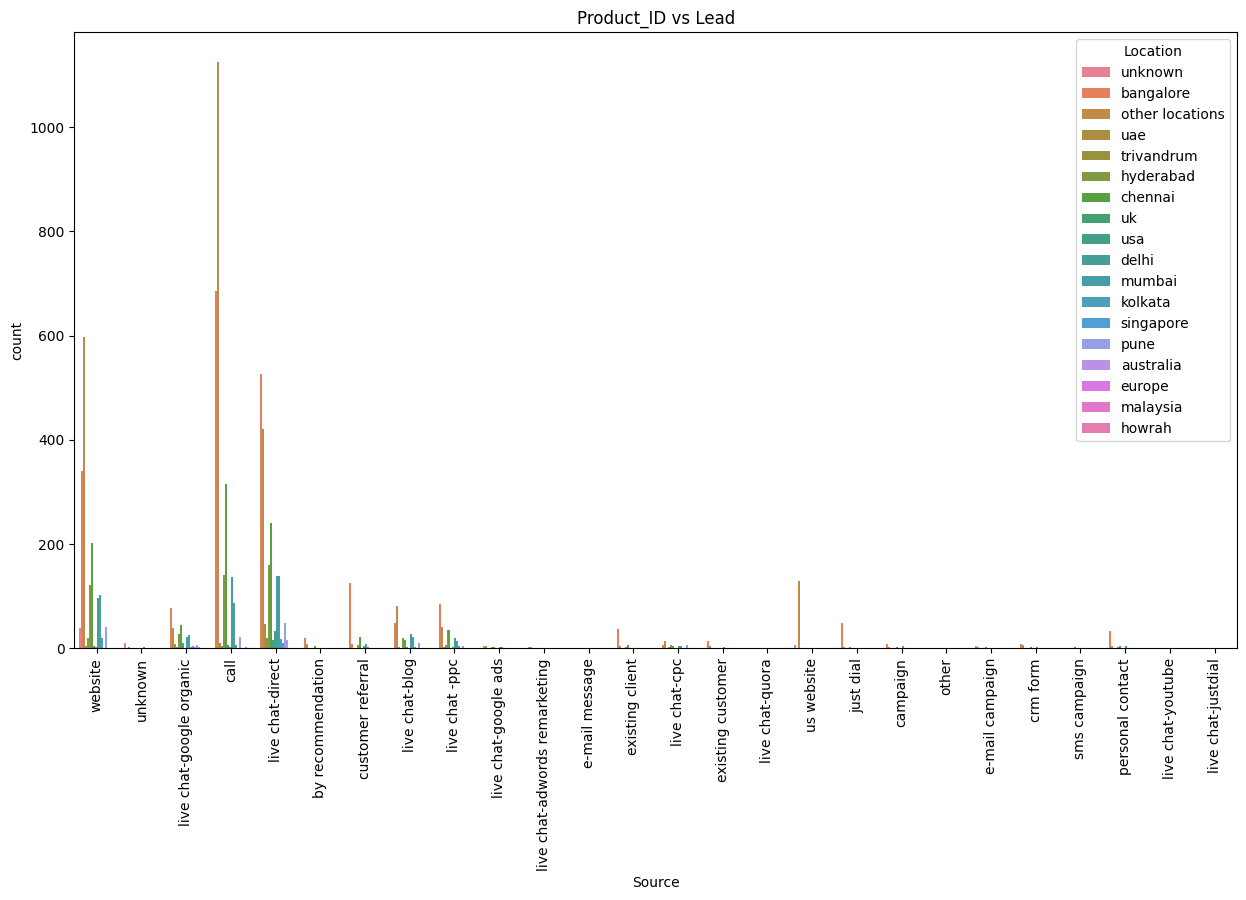

In [ ]:
# Sales_Agent vs Status
plt.figure(figsize=(15,8))
sns.countplot(x='Source', hue='Location', data=df_cleaned)
plt.title('Product_ID vs Lead')
plt.xticks(rotation=90)
plt.show()

Calls, website, and live chat–direct generate leads across multiple locations, especially Bangalore and Other locations.

Bangalore dominates almost all major sources, showing it is the primary market.

Many sources have location-specific activity, with limited geographic spread.

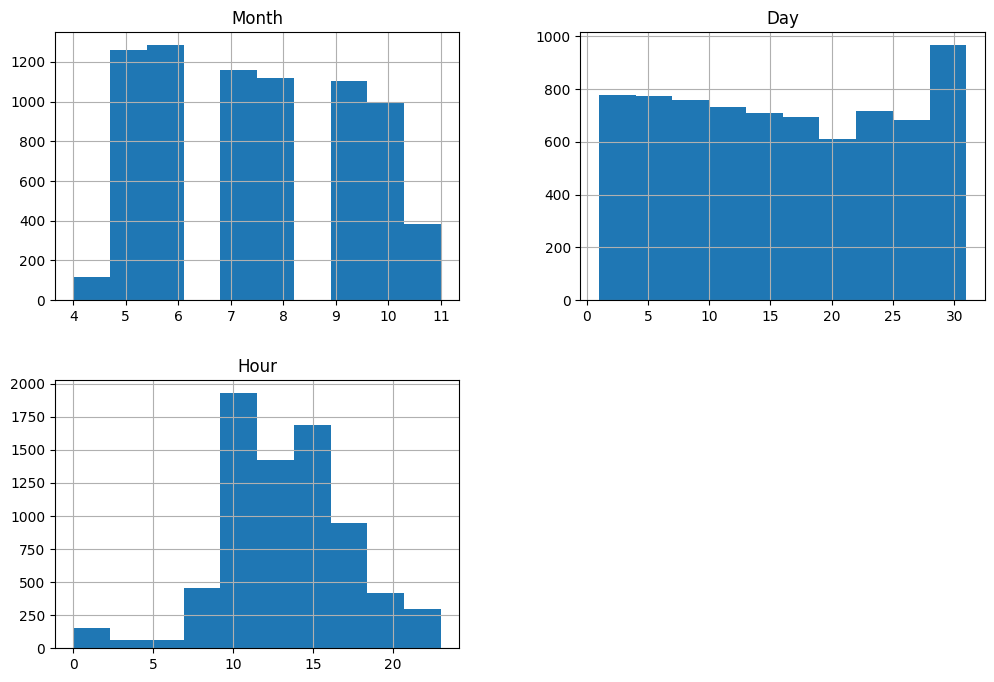

In [ ]:
# Histograms for time-based features to visualize their distributions.
df_cleaned[["Month","Day","Day_Of_Week","Hour"]].hist(figsize=(12,8))
plt.show()

Month: Leads are concentrated in a few months, indicating seasonal or campaign-based activity rather than uniform lead generation.

Day (of month): Leads are fairly spread across days, with a slight increase toward month-end.

Hour: Most leads are generated during working hours (late morning to evening), peaking around midday to afternoon.

Insight: Schedule marketing campaigns and sales follow-ups during peak hours and active months to maximize engagement.

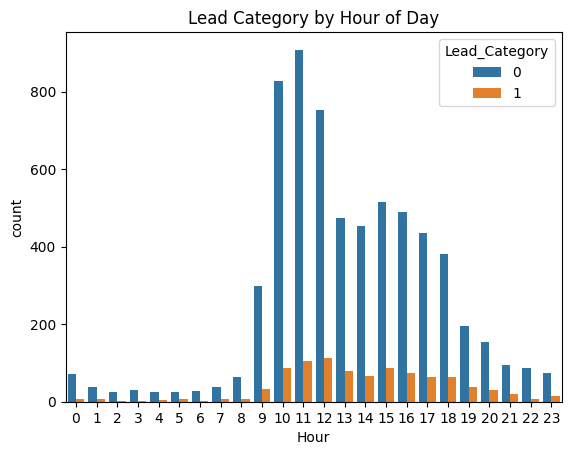

In [ ]:
# Lead Category by Hour
sns.countplot(x=df_cleaned["Hour"], hue=df_cleaned["Lead_Category"])
plt.title("Lead Category by Hour of Day")
plt.show()

Lead generation peaks during business hours, especially between 10 AM and 4 PM.

High Potential leads (1) are also concentrated in these same hours, with the highest quality leads appearing around midday.

Very few leads are generated during late night and early morning hours.

## Checking Outliers

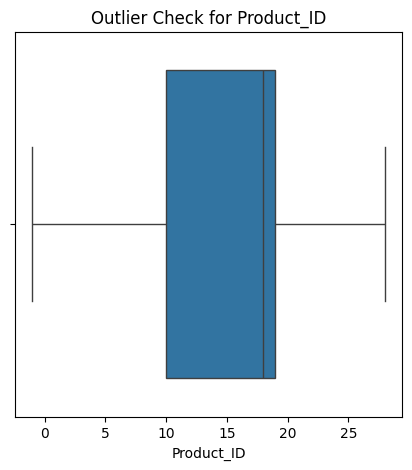

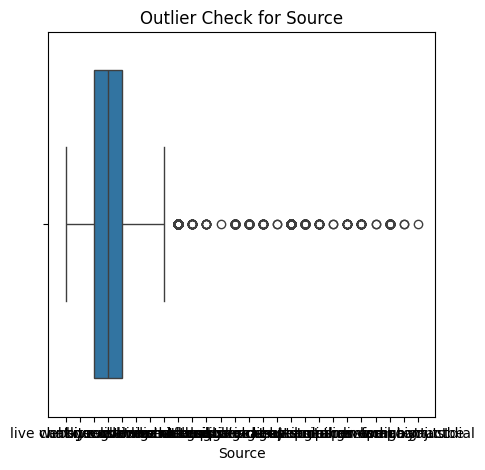

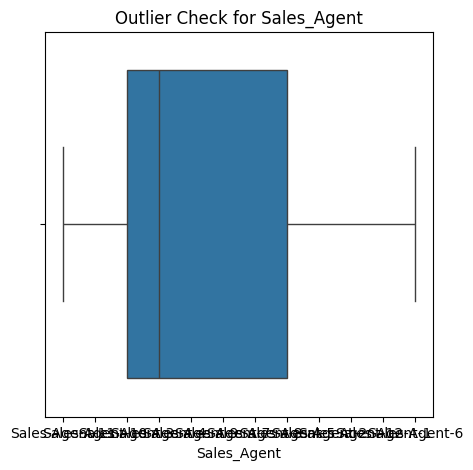

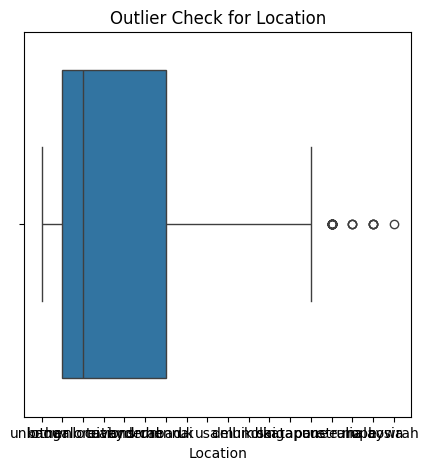

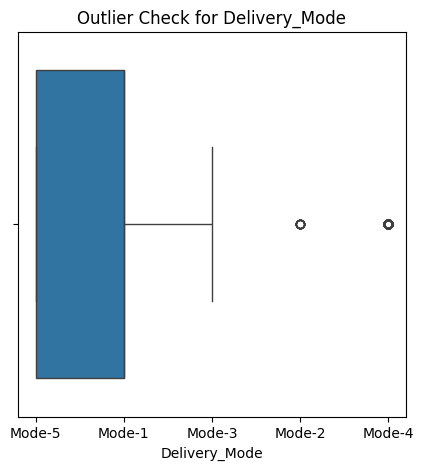

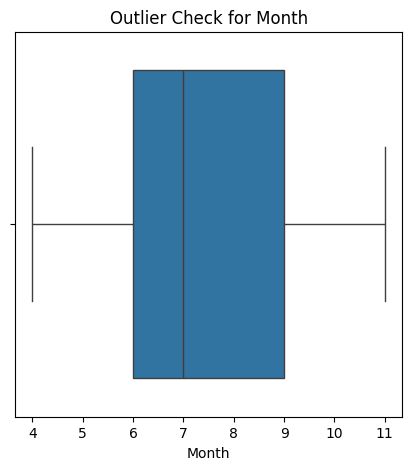

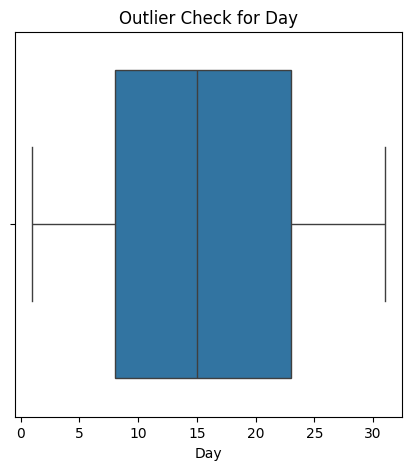

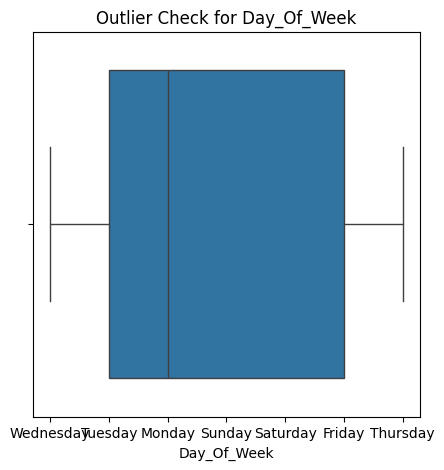

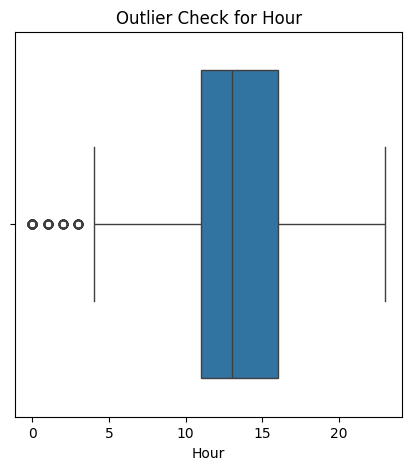

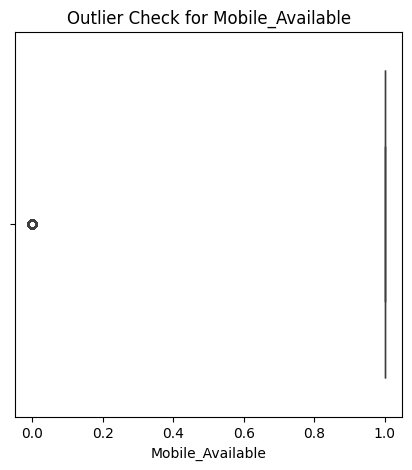

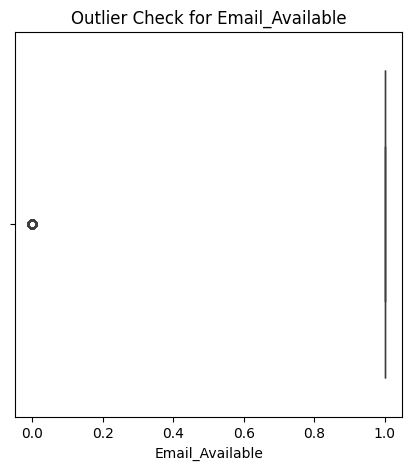

In [ ]:
# Checking outliers
numeric_cols = df_cleaned.select_dtypes(include=['int64','object','int32',]).columns

# Drop target variable
numeric_cols = numeric_cols.drop('Lead_Category')
for col in numeric_cols:
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Outlier Check for {col}")
    plt.xlabel(col)
    plt.show()



In [ ]:
# Checking outliers percentage
num_cols = df_cleaned.select_dtypes(include=['int64', 'int32']).columns

# Explicitly remove target column
num_cols = num_cols.drop('Lead_Category')
total_rows = len(df_cleaned)

for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df_cleaned[
        (df_cleaned[col] < (Q1 - 1.5 * IQR)) |
        (df_cleaned[col] > (Q3 + 1.5 * IQR))
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / total_rows) * 100

    print(f"{col}: {outlier_count} outliers ({outlier_percentage:.2f}%)")



Product_ID: 0 outliers (0.00%)
Month: 0 outliers (0.00%)
Day: 0 outliers (0.00%)
Hour: 185 outliers (2.49%)
Mobile_Available: 1810 outliers (24.39%)
Email_Available: 1699 outliers (22.90%)


## Heatmap Analysis

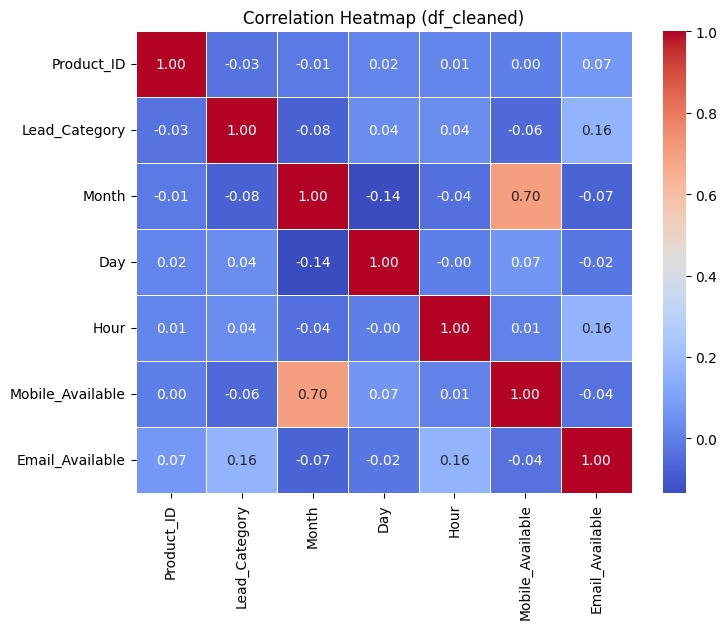

In [ ]:
# Select numeric columns only
num_df = df_cleaned.select_dtypes(include=['int64', 'int32'])
# Compute correlation matrix
corr_matrix = num_df.corr()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap (df_cleaned)")
plt.show()


There are no strong correlations between numerical features and Lead Category.

Hour and Day show a very weak positive relationship with Lead Category.

Month and Product_ID have negligible correlation, indicating limited linear influence.

Insight: Lead conversion is not driven by linear relationships alone; categorical features and non-linear models will be more effective.

## Performing One-Hot Encoding

In [ ]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_cleaned,
    drop_first=True
)


In [ ]:
# Filters and displays all rows in df_encoded that contain at least one missing value (NaN).
df_encoded[df_encoded.isna().any(axis=1)]

,Product_ID,Lead_Category,Month,Day,Hour,Mobile_Available,Email_Available,Source_call,Source_campaign,Source_crm form,...,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5,Day_Of_Week_Monday,Day_Of_Week_Saturday,Day_Of_Week_Sunday,Day_Of_Week_Thursday,Day_Of_Week_Tuesday,Day_Of_Week_Wednesday


# Train Test Split


In [ ]:
# Training,Testing and spliting the data
X = df_encoded.drop('Lead_Category', axis=1)
y = df_encoded['Lead_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [ ]:
# Evaluating DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy.score(X_test, y_test)


0.8742138364779874

In [ ]:
# Evaluating LogisticRegression
lr = LogisticRegression(
    max_iter=1000,
    C=0.5,
    class_weight='balanced'
)

lr.fit(X_train, y_train)


LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)

In [ ]:
# Evaluating Roc_Auc_Score

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_prob)


              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1946
           1       0.29      0.72      0.41       280

    accuracy                           0.74      2226
   macro avg       0.62      0.73      0.62      2226
weighted avg       0.87      0.74      0.78      2226



np.float64(0.81983556012333)

In [ ]:
# Evaluating Cross_val_score

cv_auc = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

cv_auc.mean()

np.float64(0.8192539190478267)

In [ ]:
# Evaluating GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)


In [ ]:
gb.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=10,
                           min_samples_split=20, n_estimators=200,
                           random_state=42, subsample=0.8)

In [ ]:
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]


In [ ]:
# Evaluating classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1946
           1       0.68      0.24      0.35       280

    accuracy                           0.89      2226
   macro avg       0.79      0.61      0.65      2226
weighted avg       0.87      0.89      0.87      2226



In [ ]:
# Evaluating Roc_Auc_Score

roc_auc_score(y_test, y_prob)


np.float64(0.835617016590809)

In [ ]:
# Evaluating cross_val_score

cv_auc = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

cv_auc.mean()

np.float64(0.8192539190478267)

In [ ]:
# Evaluating DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='gini',        # or 'entropy'
    max_depth=5,             # controls complexity
    min_samples_split=20,    # minimum samples to split
    min_samples_leaf=10,     # minimum samples in leaf
    class_weight='balanced', # handles imbalance
    random_state=42
)


In [ ]:
dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]


In [ ]:
# Evaluating classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.76      0.84      1946
           1       0.26      0.58      0.36       280

    accuracy                           0.74      2226
   macro avg       0.59      0.67      0.60      2226
weighted avg       0.84      0.74      0.78      2226



In [ ]:
# Evaluating Roc_Auc_Score

roc_auc_score(y_test, y_prob)


np.float64(0.7507276831595947)

In [ ]:
dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)

dt_train_score, dt_test_score


(0.7626107046592222, 0.7416891284815813)

In [ ]:
# Evaluating cross_val_score

cv_auc = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

cv_auc.mean()


np.float64(0.7557821745866542)

In [ ]:
# Evaluating RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


In [ ]:
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [ ]:
# Evaluating classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.72      0.82      1946
           1       0.27      0.73      0.39       280

    accuracy                           0.72      2226
   macro avg       0.61      0.72      0.61      2226
weighted avg       0.86      0.72      0.76      2226



In [ ]:
# Evaluating Roc_Auc_Score

roc_auc_score(y_test, y_prob)


np.float64(0.8066381588606666)

In [ ]:
rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)

rf_train_score, rf_test_score


(0.7537543319214478, 0.7178796046720575)

## Evaluating Logistic Regression ,Decision Tree, Random Forest and Gradient Boosting

In [ ]:
# Evaluating Logistic Regression ,Decision Tree, Random Forest and Gradient Boosting
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=0.5,
        class_weight='balanced'
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    )
}


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc
    })


In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by="ROC_AUC", ascending=False
)

results_df


,Model,ROC_AUC
3,Gradient Boosting,0.835617
0,Logistic Regression,0.819836
2,Random Forest,0.806638
1,Decision Tree,0.750728


## Model Comparison Graph

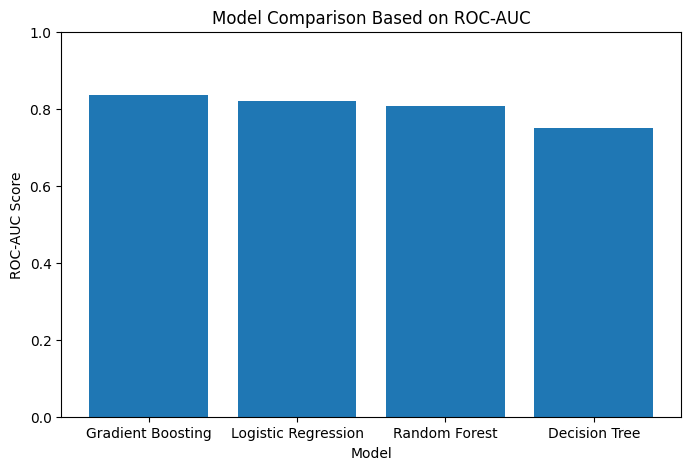

In [ ]:
#Model Comparison Graph
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison Based on ROC-AUC")
plt.ylim(0, 1)
plt.show()


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name


'Gradient Boosting'

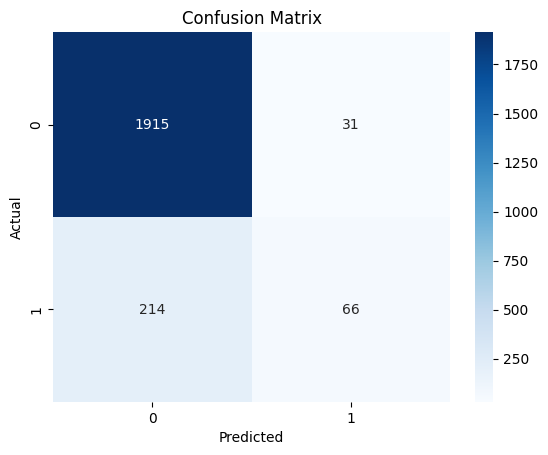

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1946
           1       0.68      0.24      0.35       280

    accuracy                           0.89      2226
   macro avg       0.79      0.61      0.65      2226
weighted avg       0.87      0.89      0.87      2226



In [ ]:
# Evaluates your trained best_model using a confusion matrix and detailed classification metrics.

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

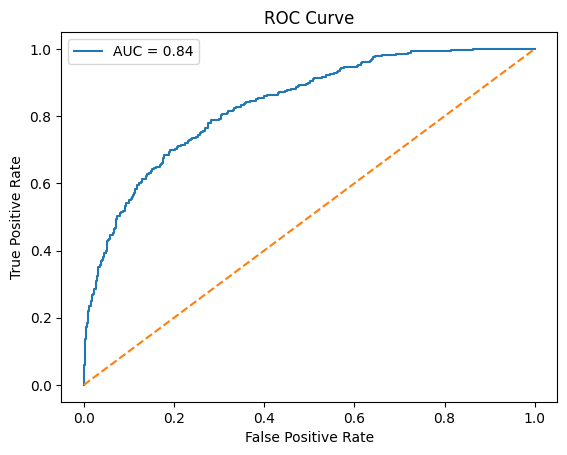

In [ ]:
# Ploting Roc_Curve, Auc

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Evaluating cross_val_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    cv_auc = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='roc_auc'
    )
    print(f"{name} CV AUC: {cv_auc.mean():.3f}")

Logistic Regression CV AUC: 0.819
Decision Tree CV AUC: 0.756
Random Forest CV AUC: 0.809
Gradient Boosting CV AUC: 0.828


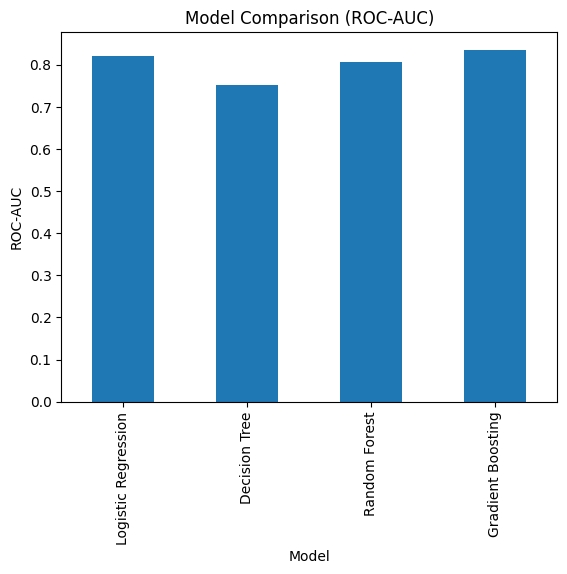

In [ ]:
# Model Comparison (ROC-AUC)
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
    auc_score = roc_auc_score(y_test, prob)
    results.append([name, auc_score])

df_results = pd.DataFrame(results, columns=["Model", "ROC_AUC"])

df_results.plot(x="Model", y="ROC_AUC", kind="bar", legend=False)
plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC")
plt.show()


 **Data Exploration Insights - Sales Effectiveness**

**Lead Status Distribution**

* Majority of leads belong to the Low Potential category.

* High Potential leads form a smaller proportion of total leads.

* This indicates that sales teams may be spending excessive time on low-conversion leads.

**Sales Agent Performance**

* Lead outcomes vary significantly across different sales agents.

* Some agents consistently handle High Potential leads, while others handle mostly Low Potential leads.

* This shows that sales effectiveness is influenced by agent capability and lead allocation.

**Lead Source Analysis**

* Certain digital lead sources produce better quality leads.

* Some sources generate high lead volume but low conversion rates.

* Focusing on quality lead sources can improve sales effectiveness and ROI.

**Location-Based Insights**

* Leads from specific locations show a higher probability of being High Potential.

* Some regions consistently produce low-quality leads.

* Region-specific sales and marketing strategies can improve conversions.

**Delivery Mode Impact**

* Certain delivery modes are more frequently associated with High Potential leads.

* Customer preference for delivery mode influences purchase decisions.

* Aligning delivery options with customer expectations can improve success rates.

**Data Preprocessing**

* Missing values were handled appropriately.

* Irrelevant and redundant columns were removed.

* Categorical variables were converted into numerical form using encoding techniques.

* The dataset was split into training and testing sets for model evaluation.

**Machine Learning Model - Lead Category Prediction**

**Problem Type**

* Binary classification problem.

* Target variable: Lead Category (High Potential / Low Potential).

**Models Implemented**

* Logistic Regression

* Gradient Boosting

* Decision Tree Classifier

* Random Forest Classifier

**Model Evaluation**

* Model performance was evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

* Random Forest showed consistent and reliable predictive performance.

**Business Impact of the ML Model**

* Automatically categorizes leads before sales engagement.

* Helps sales teams focus on High Potential leads.

* Reduces manual bias in lead classification.

* Improves sales productivity and conversion rates.

* Enables data-driven decision making for sales planning.

**Conclusion**

* Exploratory data analysis provided valuable insights into factors affecting sales effectiveness.

* Key influencing factors include sales agent performance, lead source quality, customer location, and delivery mode.

* he Random Forest model successfully predicts lead quality with good accuracy.

* Implementing this model can significantly enhance FicZon’s sales effectiveness and revenue potential.

**Future Scope**

* Integration of customer interaction and follow-up history.

* Deployment of real-time lead scoring systems.

* Integration with CRM platforms.

* Use of advanced models like Gradient Boosting or XGBoost for better performance.

# MODEL REPORT
## Sales Effectiveness & Lead Potential Prediction

##  Project Overview


**Sales Effectiveness Analysis and Lead Potential Prediction**

### Business Problem

Sales teams often spend equal effort on all leads, resulting in wasted resources on low-quality prospects. The objective of this project is to:

* Analyze sales effectiveness using historical lead data
* Predict whether a lead is **High Potential** or **Low Potential**
* Help sales teams prioritize leads more efficiently

## Exploratory Data Analysis (Sales Effectiveness)

Key insights derived from EDA:

1. **Lead Source Impact**
   Certain sources generate a higher proportion of high-potential leads.

2. **Sales Agent Performance Variability**
   Conversion rates vary significantly across sales agents, indicating scope for performance optimization.

3. **Lead Aging Effect**
   Leads contacted earlier show higher conversion probability.

4. **Contact Availability Influence**
   Leads with valid mobile and email contact details convert more frequently.

5. **Geographical and Delivery Preferences**
   Location and delivery mode show noticeable influence on lead outcomes.

These insights guided feature engineering and model selection.


## Data Preprocessing & Feature Engineering

### Steps Performed:

* Removed data leakage columns (Status)
* Created binary flags:

  * Mobile_Available
  * Email_Available
* Handled missing values using mode imputation
* Applied **One-Hot Encoding** for categorical variables

Boolean dummy variables were retained, as scikit-learn supports them natively.


##  Modeling Approach

### Models Evaluated:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier
* Gradient Boosting Classifier

### Evaluation Metrics:

* **ROC-AUC (Primary)**
* Recall for High Potential leads

Accuracy was not used as the primary metric due to class imbalance.


##  Best Model Selection

After comparing all models, **Gradient Boosting** achieved the best performance based on:

* Higher ROC-AUC score
* Better recall for High Potential leads
* Stable cross-validation performance

### Reasons for Selection:

* Captures non-linear relationships
* Handles categorical interactions well
* Controlled model complexity reduces overfitting


Cross-validation scores closely matched test performance, indicating model stability.

## Feature Importance Insights

Top contributing features included:

* Lead source
* Lead age
* Sales agent
* Contact availability flags
* Location

These features directly align with sales process optimization.

## Business Recommendations

1. Prioritize leads from high-performing sources
2. Enforce faster follow-up for new leads
3. Replicate best practices from top-performing agents
4. Improve data quality by ensuring contact availability
5. Use model predictions to dynamically rank incoming leads



